# GAME — Genetic Algorithms with Marginalised Ensembles
**Paper:** M. Peronaci, M. Martinelli, S. Nesseris (2026) [arXiv:2602.12870](https://arxiv.org/abs/2602.12870)  
**Code:** https://github.com/matteoperonaci/GAME

This notebook demonstrates the full GAME pipeline on a generic function reconstruction. In this example it will be the Hubble rate $H(z)$.

All core logic (chi2 marginalisation, roughness, L-curve elbow, weights) lives in `ga_toolkit_v3.py`.

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from scipy.optimize import minimize
from sympy import symbols, lambdify, diff, nsimplify
import matplotlib.pyplot as plt
import random as rnd
from joblib import Parallel, delayed

import ga_toolkit_v3 as ga

## 1. Data

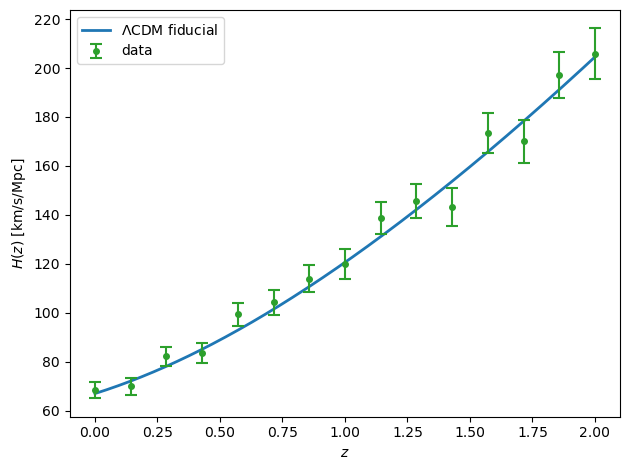

In [2]:
# ── Settings ───────────────────────────────────────────────────────────────────
use_real_data = False
use_mock_data = True

#mock data settings
ndat               = 15
use_uniform_z_space = True
error_fact         = 0.05
zlims              = [0., 2.]

# Grid used for plotting and roughness integration throughout the notebook
zplot = np.linspace(zlims[0], zlims[1], 300)

# ── Fiducial model: flat ΛCDM ──────────────────────────────────────────────────
omegam0fid = 0.32
H0fid      = 67.       # km/s/Mpc

def Hfid(z):
    return H0fid * np.sqrt(omegam0fid * (1 + z)**3 + 1 - omegam0fid)

# ── Load / generate data ───────────────────────────────────────────────────────
if use_real_data:
    zart, Hzart, Hzart_err = np.loadtxt('real_data/H_data.txt', skiprows=1, unpack=True)
    mask = zart < zlims[1]
    zart, Hzart, Hzart_err = zart[mask], Hzart[mask], Hzart_err[mask]

if use_mock_data:
    zmock, Hzmock, Hzmock_err = ga.generate_mock(
        ndat=ndat, xlims=zlims,
        use_uniform_z_space=use_uniform_z_space,
        fiducial_function=Hfid,
        error_fact=error_fact,
    )

# Combine or select dataset
if use_real_data and use_mock_data:
    zdata  = np.concatenate((zart, zmock))
    Hz     = np.concatenate((Hzart, Hzmock))
    Hz_err = np.concatenate((Hzart_err, Hzmock_err))
elif use_real_data:
    zdata, Hz, Hz_err = zart, Hzart, Hzart_err
else:
    zdata, Hz, Hz_err = zmock, Hzmock, Hzmock_err

ndat = len(zdata)

# ── Quick plot ─────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(zplot, Hfid(zplot), label=r'$\Lambda$CDM fiducial', color='C0', lw=2)
plt.errorbar(zdata, Hz, yerr=Hz_err, color='C2',
             capsize=4, capthick=1.5, ls='', marker='o', markersize=4, label='data')
plt.xlabel(r'$z$');  plt.ylabel(r'$H(z)$ [km/s/Mpc]');  plt.legend()
plt.tight_layout();  plt.show()

## 2. Threshold $\chi^2$ (parametric baseline)

In [3]:
def chi2_parametric(params):
    om0, H0 = params
    model   = H0 * np.sqrt(om0 * (1 + zdata)**3 + 1 - om0)
    return np.sum(((Hz - model) / Hz_err)**2)

result_bf      = minimize(chi2_parametric, [omegam0fid, H0fid], method='Nelder-Mead')
chi2_threshold = result_bf.fun
om_bf, H0_bf   = result_bf.x

print(f'chi2 fiducial  = {chi2_parametric([omegam0fid, H0fid]):.3f}')
print(f'chi2 threshold = {chi2_threshold:.3f}')
print(f'best-fit Omega_m = {om_bf:.4f},  H0 = {H0_bf:.3f}')

chi2 fiducial  = 10.071
chi2 threshold = 8.936
best-fit Omega_m = 0.3130,  H0 = 68.347


## 3. GA Setup

In [4]:
# ── Offset type ────────────────────────────────────────────────────────────────
# qchi=0: additive        y(x) = y0 + f_GA(x)
# qchi=1: multiplicative  y(x) = y0 * f_GA(x)  ← recommended for H(z)
qchi = 1

# ── Physical prior on the GA shape ────────────────────────────────────────────
# func_prior(x, GA_value) wraps the raw GA output into the model value.
# Examples:
#   lambda x, GAx: GAx                          (no prior — identity)
#   lambda x, GAx: (1 + (1+x)**3 * GAx**2)**0.5 (ΛCDM-like shape prior)
def GA_prior(x, GAx):
    return GAx

# ── GA fitness function ────────────────────────────────────────────────────────
# Uses the toolkit's marginalised chi2 (Eq. 2.11), which analytically integrates
# out the constant offset y0 so the GA never wastes generations fitting a scale.
def chi2_GA(kid, gram):
    return ga.compute_marginalised_chi2(kid, gram, zdata, Hz, Hz_err, GA_prior, qchi)

# ── Hyperparameter grid ────────────────────────────────────────────────────────
grammar_list = [['poly', 'exp', 'cpl'],
                ['cplexp', 'exp', 'cpl'],
                ['poly', 'cplexp', 'cpl']] # different grammar sets to test, see ga_toolkit_v3.py for all available options
cross_list   = [0.95]                      # crossover rates to test
mut_list     = [0.95]                      # mutation rates to test
n_seeds      = 20                          # number of random seeds (independent runs) per hyperparameter combination
seed_list    = [rnd.randint(0, 100_000) for _ in range(n_seeds)]
n_chains     = n_seeds * len(cross_list) * len(mut_list) * len(grammar_list)
print(f'Total chains: {n_chains}')

# ── Base input_params (per-chain overrides applied in the runner below) ────────
input_params = {
    'Nchains'      : n_chains,
    'Ngens'        : 1000,                  # number of generations to evolve each chain for
    'Npops'        : 100,                  # population size (number of candidate expressions per generation)
    'length'       : 4,
    'selectionrate': 0.5,                  # fraction of the population replaced each generation
    'toursize'     : 4,
    'verbose'      : False,
    'GA_prior'     : f'f(x) = {GA_prior(symbols("x"), symbols("GA"))}',
}

Total chains: 60


## 4. Run the GA ensemble (parallel)

In [5]:
def run_single_chain(seed, crossover_rate, mutation_rate, grammar):
    params = input_params.copy()
    params['Nseed']         = seed
    params['crossoverrate'] = crossover_rate
    params['mutationrate']  = mutation_rate
    params['grammar']       = grammar
    params['ranges']        = [[-1, 1],           # outer continuous coefficient/amplitude
                               [0, len(grammar)], # basis function choice from grammar
                               [0, 2],            # inner continuous scaling factor applied to x
                               [0, 10]]           # integer exponent the function is raised to
                            # (be careful with specific grammar choices, e.g log can produce NaNs for negative inputs, so you might want to restrict the ranges accordingly)
    return {
        'seed'     : seed,
        'crossover': crossover_rate,
        'mutation' : mutation_rate,
        'grammar'  : grammar,
        'run_chain': ga.evolution(chi2_GA, params, grammar),
    }

n_jobs = -1 # use all available CPU cores, set to e.g. 4 to use only 4 cores
chain_results = Parallel(n_jobs=n_jobs, verbose=5)(
    delayed(run_single_chain)(seed, cross, mut, gram)
    for seed  in seed_list
    for cross in cross_list
    for mut   in mut_list
    for gram  in grammar_list
)

# Unpack results
run          = [r['run_chain'] for r in chain_results]
bfps         = [[row[0] for row in r['run_chain']] for r in chain_results]
seedchain    = [r['seed']      for r in chain_results]
crosschain   = [r['crossover'] for r in chain_results]
mutchain     = [r['mutation']  for r in chain_results]
grammarchain = [r['grammar']   for r in chain_results]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done  58 out of  60 | elapsed:   33.6s remaining:    1.2s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   33.8s finished


## 5. $\chi^2$ evolution plot

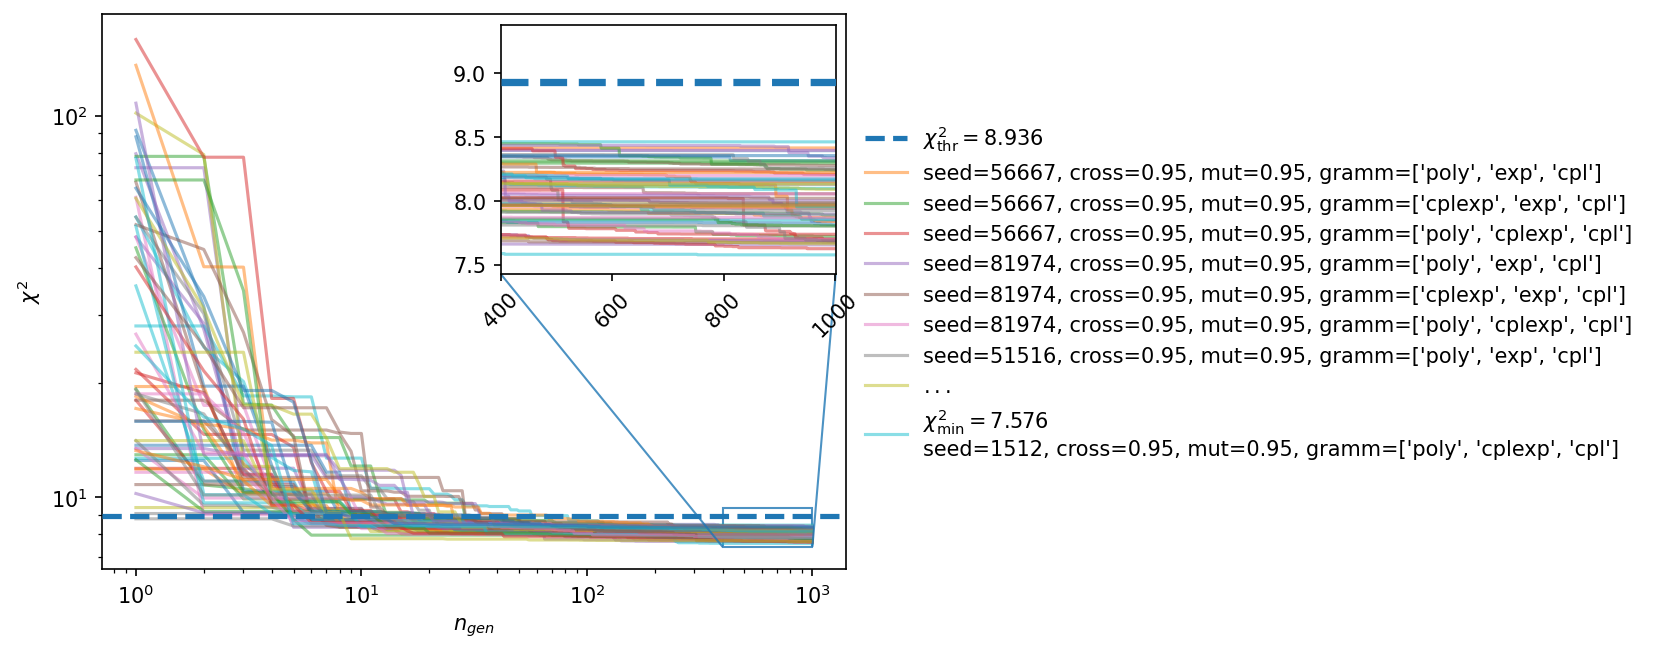

In [6]:
ga.plot_chi2_evolution(
    bfps, chi2_threshold, input_params,
    seedchain, crosschain, mutchain, grammarchain,
    dpi=150,
)

## 6. GAME — collect expressions and compute weights

In [7]:
# Collect symbolic expressions (one per chain) and their roughness values.
# expr_list holds the individual analytic GA best-fit expressions f_j,GA.
chi2_arr, R_arr, expr_list, f_list = ga.collect_expressions(
    run, bfps, grammarchain,
    zdata, Hz, Hz_err, GA_prior, zplot,
    qchi=qchi,
    n_jobs=-1,
    simplify=True,
)

# Compute GAME weights via L-curve elbow selection (Sec. 2.3.1).
# Returns: normalised weights w, lambda_elbow, and f_game (a numerical callable
# for f_GAME(x) = sum_j w_j * f_j,GA(x), paper Eq. 2.24).
# Note: individual analytic expressions are in expr_list.
w, lambda_elbow, f_game = ga.compute_game_weights(
    chi2_arr, R_arr, expr_list, f_list,
)

xs = symbols('x')

def H_game(z):      # GAME reconstruction (Eq. 2.24)
    return f_game(z)

chi2_game = np.sum(((H_game(zdata) - Hz) / Hz_err) ** 2)
print(f'lambda_elbow = {lambda_elbow:.3e}')
print(f'GAME chi2    = {chi2_game:.3f}')

lambda_elbow = 9.307e-05
GAME chi2    = 7.914


## 7. L-curve

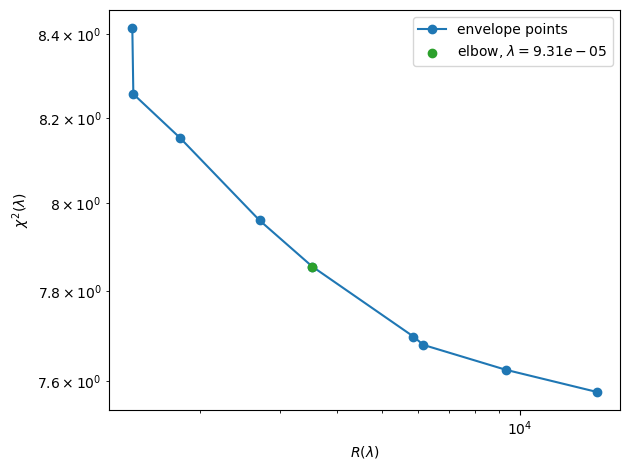

In [8]:
# 7. L-curve (chi2 vs roughness for envelope models)
# Recompute envelope for plotting
lambda_grid = np.logspace(-30, 10, 10_000)
J           = chi2_arr[None, :] + lambda_grid[:, None] * R_arr[None, :]
env_indices = np.unique(np.argmin(J, axis=1))
order       = np.argsort(R_arr[env_indices])
env_indices = env_indices[order]

R_env    = R_arr[env_indices]
chi2_env = chi2_arr[env_indices]

plt.figure()
plt.loglog(R_env, chi2_env, marker='o', label='envelope points')
# Mark the elbow model
S_env    = chi2_env + lambda_elbow * R_env
elbow_k  = np.argmin(S_env)
plt.scatter(R_env[elbow_k], chi2_env[elbow_k], color='C2', zorder=5,
            label=fr'elbow, $\lambda = {lambda_elbow:.2e}$')
plt.xlabel(r'$R(\lambda)$');  plt.ylabel(r'$\chi^2(\lambda)$');  plt.legend()
plt.tight_layout();  plt.show()

## 8. Best-fit ($\chi^2_{\rm min}$) single GA solution

In [9]:
# Standard GA best-fit: the single chain with the minimum chi2 (Sec. 2.2).
# expr_ga is the analytic symbolic expression; H_ga is its callable.
idx_ga    = int(np.argmin(chi2_arr))
expr_ga   = expr_list[idx_ga]
f_ga_lam  = lambdify(xs, expr_ga, ['numpy', 'scipy'])

def H_ga(z):
    return f_ga_lam(z)

print(f'GA minimum chi2 = {chi2_arr[idx_ga]:.3f}')

GA minimum chi2 = 7.576


## 9. Error bands (path-integral + ensemble variance)

In [10]:
# ── GA minimum: path-integral band ────────────────────────────────────────────
dH_ga_pi = ga.compute_dfuncGA(zdata, Hz, Hz_err, H_ga, grade=2, starting_guess=1e-5, qchi=qchi)

# ── GAME: path-integral band ───────────────────────────────────────────────────
dH_game_pi = ga.compute_dfuncGA(zdata, Hz, Hz_err, H_game, grade=2, starting_guess=1e-3, qchi=qchi)

# ── GAME: ensemble variance (paper Eq. 2.25) ───────────────────────────────────
# sigma^2_ens(x) = sum_j w_j^2 * (f_j,GA(x) - f_GAME(x))^2
f_i_z      = np.array([f(zplot) for f in f_list])   # shape (N_conf, len(zplot))
H_game_z   = H_game(zplot)                           # f_GAME evaluated on the plot grid
var_ens_H  = np.sum((w**2)[:, None] * (f_i_z - H_game_z)**2, axis=0)

# ── Total 1-sigma GAME uncertainty (paper Eq. 2.26) ───────────────────────────
# sigma^2_tot = delta_f^2_PI + sigma^2_ens
# Note: var_ens_H is a fixed array on zplot; dH_game is valid only when called with zplot.
def dH_game(z):
    return np.sqrt(dH_game_pi(z)**2 + var_ens_H)

def dH_ga(z):
    return dH_ga_pi(z)

## 10. $H(z)$ reconstruction

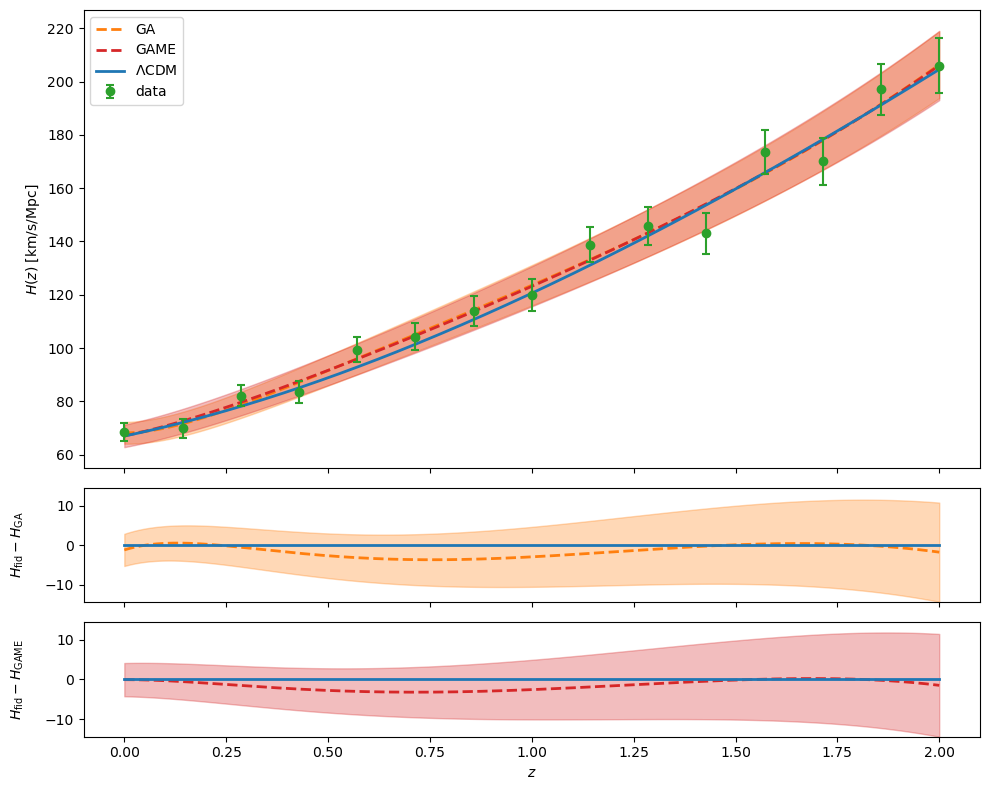

In [11]:
H_ga_z    = H_ga(zplot)
dH_ga_z   = dH_ga(zplot)
H_game_z  = H_game(zplot)
dH_game_z = dH_game(zplot)
Hfid_z    = Hfid(zplot)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, sharex=True,
    gridspec_kw={'height_ratios': [4, 1, 1]},
    figsize=(10, 8),
)

# GA minimum
ax1.plot(zplot, H_ga_z, label='GA',  color='C1', lw=2, ls='--')
ax1.fill_between(zplot, H_ga_z - dH_ga_z, H_ga_z + dH_ga_z, color='C1', alpha=0.3)
ax2.plot(zplot, Hfid_z - H_ga_z, color='C1', lw=2, ls='--')
ax2.fill_between(zplot, (Hfid_z - H_ga_z) - dH_ga_z, (Hfid_z - H_ga_z) + dH_ga_z, color='C1', alpha=0.3)

# GAME
ax1.plot(zplot, H_game_z, label='GAME', color='C3', lw=2, ls='--')
ax1.fill_between(zplot, H_game_z - dH_game_z, H_game_z + dH_game_z, color='C3', alpha=0.3)
ax3.plot(zplot, Hfid_z - H_game_z, color='C3', lw=2, ls='--')
ax3.fill_between(zplot, (Hfid_z - H_game_z) - dH_game_z, (Hfid_z - H_game_z) + dH_game_z, color='C3', alpha=0.3)

# Fiducial + data
ax1.plot(zplot, Hfid_z, label=r'$\Lambda$CDM', color='C0', lw=2, alpha=1.0)
ax1.errorbar(zdata, Hz, yerr=Hz_err, color='C2', capsize=3, capthick=1.5, ls='', marker='o', alpha=1.0, label='data')
ax2.plot(zplot, 0 * zplot, color='C0', lw=2, alpha=1.0)
ax3.plot(zplot, 0 * zplot, color='C0', lw=2, alpha=1.0)

ax1.set_ylabel(r'$H(z)$ [km/s/Mpc]')
ax2.set_ylabel(r'$H_{\rm fid} - H_{\rm GA}$', labelpad=13)
ax3.set_ylabel(r'$H_{\rm fid} - H_{\rm GAME}$', labelpad=13)
ax3.set_xlabel(r'$z$')
ax1.legend()

y_lim = max(
    abs((Hfid_z - H_ga_z - dH_ga_z).min()), abs((Hfid_z - H_ga_z + dH_ga_z).max()),
    abs((Hfid_z - H_game_z - dH_game_z).min()), abs((Hfid_z - H_game_z + dH_game_z).max()),
)
ax2.set_ylim(-y_lim, y_lim)
ax3.set_ylim(-y_lim, y_lim)
plt.tight_layout();  plt.show()

## 11. $H'(z)$ derivative

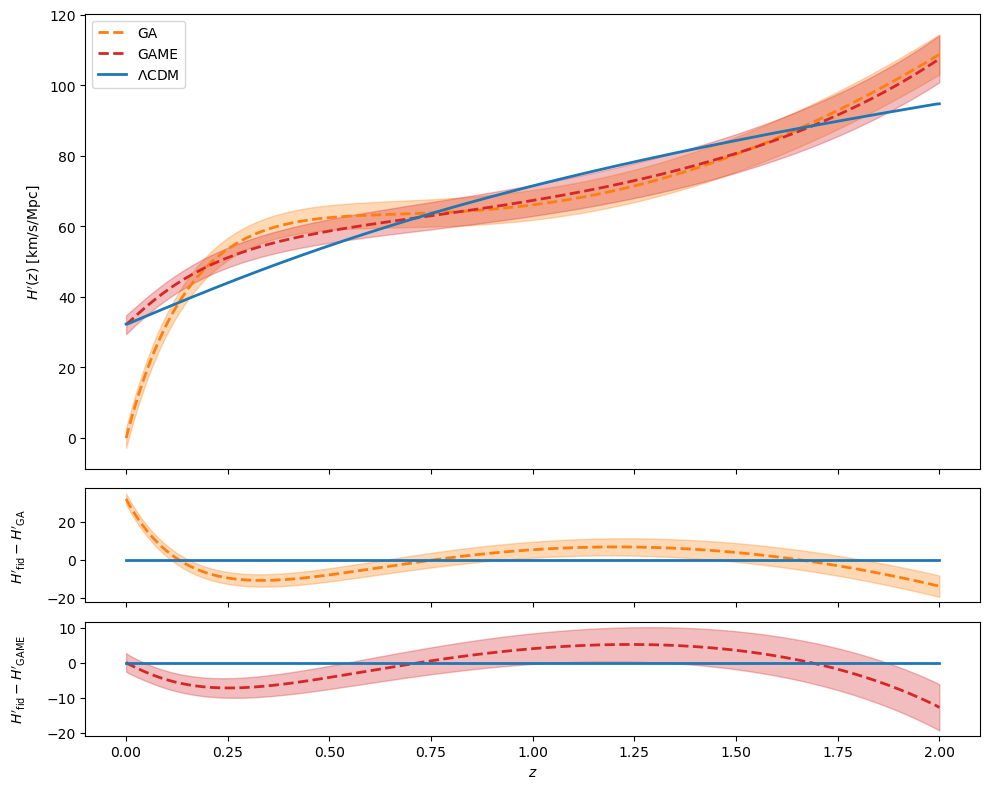

In [12]:
# ── GA minimum: analytic derivative of the best-fit symbolic expression ────────
der_ga   = diff(expr_ga, xs)
H1_ga_z  = lambdify(xs, der_ga, ['numpy', 'scipy'])(zplot)
dH1_ga_z = np.gradient(dH_ga_pi(zplot), zplot)   # propagate path-integral band

# ── GAME: analytic derivatives of each individual GA expression ────────────────
# f'_GAME(x) = sum_j w_j * f'_j,GA(x)  (paper Eq. 2.27)
# Computed as a weighted average of the analytic symbolic derivatives,
# which is equivalent to (and more accurate than) differentiating f_GAME numerically.
f1_i_z   = np.array([
    lambdify(xs, diff(expr, xs), ['numpy', 'scipy'])(zplot)
    for expr in expr_list
])                                                 # shape (N_conf, len(zplot))
H1_game_z = np.einsum('j,jk->k', w, f1_i_z)      # f'_GAME (Eq. 2.27)

# ── GAME: ensemble variance on the derivative (paper Eq. 2.28) ────────────────
# sigma^2_ens(f')(x) = sum_j w_j^2 * (f'_j,GA(x) - f'_GAME(x))^2
var_ens_dH = np.sum((w**2)[:, None] * (f1_i_z - H1_game_z)**2, axis=0)

# ── GAME: total 1-sigma uncertainty on the derivative (paper Eq. 2.30) ────────
dH1_game_z = np.sqrt(np.gradient(dH_game_pi(zplot), zplot)**2 + var_ens_dH)

def H1fid(z):
    return np.gradient(Hfid(z), z)

H1fid_z = H1fid(zplot)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, sharex=True,
    gridspec_kw={'height_ratios': [4, 1, 1]},
    figsize=(10, 8),
)

ax1.plot(zplot, H1_ga_z,   label='GA',   color='C1', lw=2, ls='--')
ax1.fill_between(zplot, H1_ga_z - dH1_ga_z, H1_ga_z + dH1_ga_z, color='C1', alpha=0.3)
ax2.plot(zplot, H1fid_z - H1_ga_z, color='C1', lw=2, ls='--')
ax2.fill_between(zplot, (H1fid_z - H1_ga_z) - dH1_ga_z, (H1fid_z - H1_ga_z) + dH1_ga_z, color='C1', alpha=0.3)

ax1.plot(zplot, H1_game_z, label='GAME', color='C3', lw=2, ls='--')
ax1.fill_between(zplot, H1_game_z - dH1_game_z, H1_game_z + dH1_game_z, color='C3', alpha=0.3)
ax3.plot(zplot, H1fid_z - H1_game_z, color='C3', lw=2, ls='--')
ax3.fill_between(zplot, (H1fid_z - H1_game_z) - dH1_game_z, (H1fid_z - H1_game_z) + dH1_game_z, color='C3', alpha=0.3)

ax1.plot(zplot, H1fid_z, label=r'$\Lambda$CDM', color='C0', lw=2, alpha=1.0)
ax2.plot(zplot, 0 * zplot, color='C0', lw=2, alpha=1.0)
ax3.plot(zplot, 0 * zplot, color='C0', lw=2, alpha=1.0)

ax1.set_ylabel(r"$H'(z)$ [km/s/Mpc]")
ax2.set_ylabel(r"$H'_{\rm fid} - H'_{\rm GA}$", labelpad=13)
ax3.set_ylabel(r"$H'_{\rm fid} - H'_{\rm GAME}$", labelpad=13)
ax3.set_xlabel(r'$z$')
ax1.legend()
plt.tight_layout();  plt.show()

## 12. Cumulative $\chi^2$

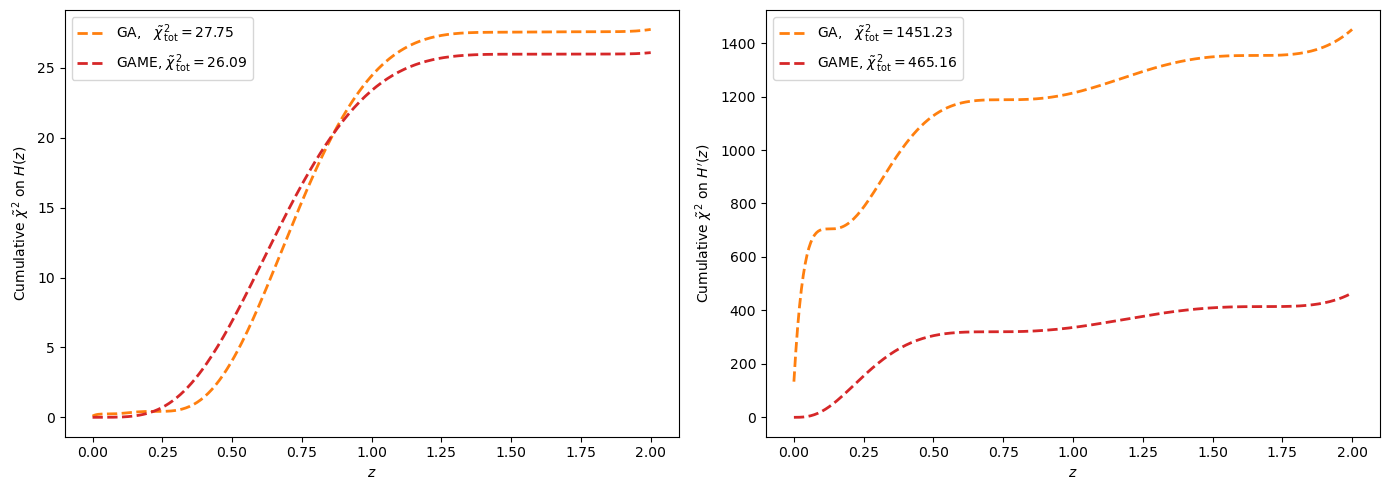

In [13]:
def cumchi2(f_vals, fid_vals, err_vals):
    return np.cumsum(((fid_vals - f_vals) / err_vals) ** 2)

cc_H_ga    = cumchi2(H_ga_z,   Hfid_z,  dH_ga_z)
cc_H_game  = cumchi2(H_game_z, Hfid_z,  dH_game_z)
cc_H1_ga   = cumchi2(H1_ga_z,  H1fid_z, dH1_ga_z)
cc_H1_game = cumchi2(H1_game_z,H1fid_z, dH1_game_z)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

axL.plot(zplot, cc_H_ga,   color='C1', lw=2, ls='--', label=fr'GA,   $\tilde\chi^2_{{\rm tot}}={cc_H_ga[-1]:.2f}$')
axL.plot(zplot, cc_H_game, color='C3', lw=2, ls='--', label=fr'GAME, $\tilde\chi^2_{{\rm tot}}={cc_H_game[-1]:.2f}$')
axL.set_xlabel(r'$z$');  axL.set_ylabel(r'Cumulative $\tilde\chi^2$ on $H(z)$');  axL.legend()

axR.plot(zplot, cc_H1_ga,   color='C1', lw=2, ls='--', label=fr"GA,   $\tilde\chi^2_{{\rm tot}}={cc_H1_ga[-1]:.2f}$")
axR.plot(zplot, cc_H1_game, color='C3', lw=2, ls='--', label=fr"GAME, $\tilde\chi^2_{{\rm tot}}={cc_H1_game[-1]:.2f}$")
axR.set_xlabel(r'$z$');  axR.set_ylabel(r"Cumulative $\tilde\chi^2$ on $H'(z)$");  axR.legend()

plt.tight_layout();  plt.show()

## 13. Ensemble spread

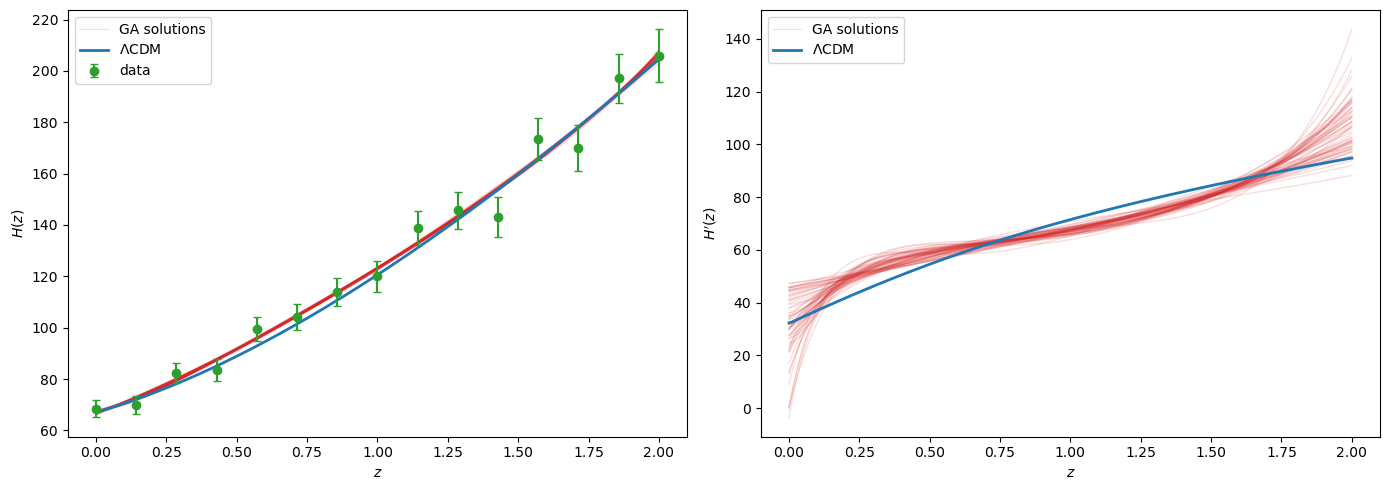

In [14]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

for i, f_i in enumerate(f_list):
    h_i  = f_i(zplot)
    dh_i = np.gradient(h_i, zplot, edge_order=2)
    axL.plot(zplot, h_i,  color='C3', alpha=0.15, lw=1.0, label='GA solutions' if i == 0 else '')
    axR.plot(zplot, dh_i, color='C3', alpha=0.15, lw=1.0, label='GA solutions' if i == 0 else '')

axL.plot(zplot, Hfid_z, color='C0', lw=2, alpha=1.0, label=r'$\Lambda$CDM')
axL.errorbar(zdata, Hz, yerr=Hz_err, color='C2', capsize=3, ls='', marker='o', alpha=1.0, label='data')
axL.set_xlabel(r'$z$');  axL.set_ylabel(r'$H(z)$');  axL.legend()

axR.plot(zplot, H1fid_z, color='C0', lw=2, alpha=1.0, label=r'$\Lambda$CDM')
axR.set_xlabel(r'$z$');  axR.set_ylabel(r"$H'(z)$");  axR.legend()

plt.tight_layout();  plt.show()